# Estimación por Máxima Verosimilitud (MLE)

**Simulaciones y Procesos Estocásticos — UCA 2026**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 1. La función de verosimilitud: visualización

Media muestral: 1.660 (teórico: 2.0)


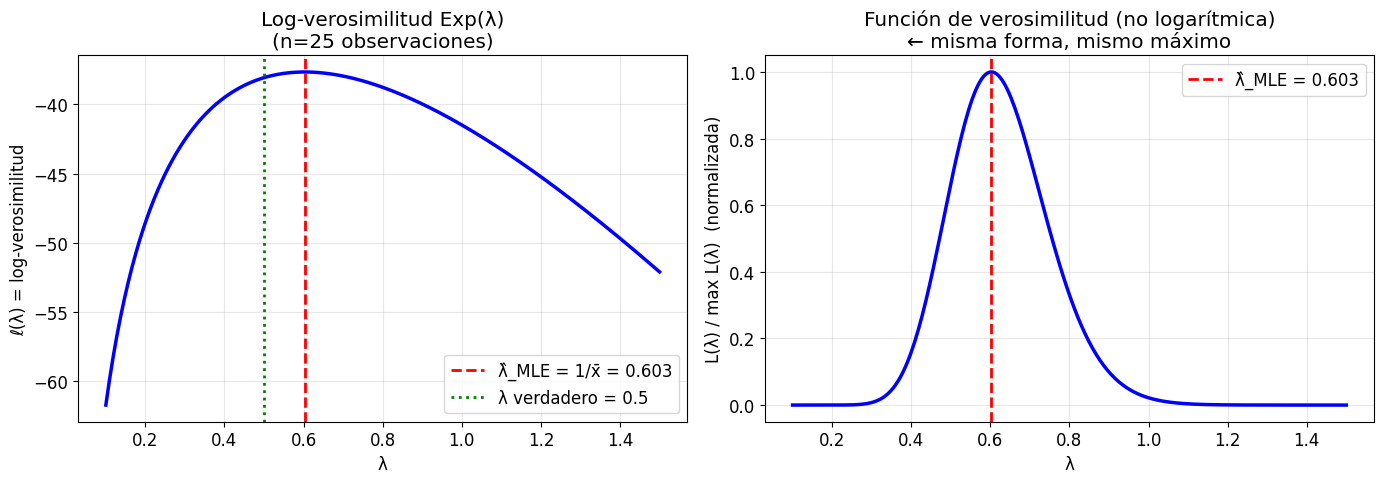

In [2]:
# Datos: tiempos entre llegadas de clientes
# Supuesto: Exponencial(lambda)
lambda_true = 0.5  # tasa verdadera
n = 25
datos = np.random.exponential(scale=1/lambda_true, size=n)

print(f"Media muestral: {datos.mean():.3f} (teórico: {1/lambda_true:.1f})")

# Función de log-verosimilitud para Exp(lambda)
# ell(lambda) = n*log(lambda) - lambda * sum(x_i)
def log_lik_exp(lam, data):
    if lam <= 0:
        return -np.inf
    return len(data) * np.log(lam) - lam * np.sum(data)

# Graficar la log-verosimilitud
lam_grid = np.linspace(0.1, 1.5, 300)
ll_values = [log_lik_exp(l, datos) for l in lam_grid]

# MLE analítico: lambda_hat = 1/x_bar
lambda_hat = 1 / datos.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(lam_grid, ll_values, 'b-', lw=2.5)
ax.axvline(lambda_hat, color='red', lw=2, ls='--', 
           label=f'λ̂_MLE = 1/x̄ = {lambda_hat:.3f}')
ax.axvline(lambda_true, color='green', lw=2, ls=':', 
           label=f'λ verdadero = {lambda_true}')
ax.set_xlabel('λ')
ax.set_ylabel('ℓ(λ) = log-verosimilitud')
ax.set_title(f'Log-verosimilitud Exp(λ)\n(n={n} observaciones)')
ax.legend()
ax.grid(True, alpha=0.3)

# Verosimilitud (no log) — se nota por qué trabajamos con log
ax = axes[1]
lik_values = np.exp(np.array(ll_values) - max(ll_values))  # normalizada
ax.plot(lam_grid, lik_values, 'b-', lw=2.5)
ax.axvline(lambda_hat, color='red', lw=2, ls='--', label=f'λ̂_MLE = {lambda_hat:.3f}')
ax.set_xlabel('λ')
ax.set_ylabel('L(λ) / max L(λ)  (normalizada)')
ax.set_title('Función de verosimilitud (no logarítmica)\n← misma forma, mismo máximo')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. MLE analítico para distribuciones comunes

In [15]:
# Comparar MLE analítico con scipy para varias distribuciones

# --- Normal ---
mu_true, sigma_true = 5.0, 2.0
datos_normal = np.random.normal(mu_true, sigma_true, size=100)

mu_hat = datos_normal.mean()
sigma_hat = datos_normal.std(ddof=0)  # MLE usa n, no n-1

mu_scipy, sigma_scipy = stats.norm.fit(datos_normal)

print("=== MLE para Normal(μ, σ) ===")
print(f"  True:     μ={mu_true}, σ={sigma_true}")
print(f"  Analítico: μ̂=x̄={mu_hat:.4f}, σ̂={(sigma_hat):.4f}")
print(f"  scipy:    μ̂={mu_scipy:.4f}, σ̂={sigma_scipy:.4f}")

# --- Poisson ---
lam_pois = 3.5
datos_poisson = np.random.poisson(lam_pois, size=100)
lambda_hat_pois = datos_poisson.mean()

print(f"\n=== MLE para Poisson(λ) ===")
print(f"  True:     λ={lam_pois}")
print(f"  Analítico: λ̂=x̄={lambda_hat_pois:.4f}")

# --- Bernoulli ---
p_true = 0.35
datos_bernoulli = np.random.binomial(1, p_true, size=200)
p_hat = datos_bernoulli.mean()

print(f"\n=== MLE para Bernoulli(p) ===")
print(f"  True:     p={p_true}")
print(f"  Analítico: p̂=x̄={p_hat:.4f}")

=== MLE para Normal(μ, σ) ===
  True:     μ=5.0, σ=2.0
  Analítico: μ̂=x̄=5.1837, σ̂=1.9955
  scipy:    μ̂=5.1837, σ̂=1.9955

=== MLE para Poisson(λ) ===
  True:     λ=3.5
  Analítico: λ̂=x̄=3.5700

=== MLE para Bernoulli(p) ===
  True:     p=0.35
  Analítico: p̂=x̄=0.3550


## 3. MLE numérico para distribución Gamma

La distribución Gamma(α, β) no tiene solución analítica cerrada para α. Necesitamos optimización numérica.

=== MLE numérico para Gamma(α, β) ===
  True:          α=2.0, β=0.5
  Nelder-Mead:   α̂=2.2294, β̂=0.5972
  scipy.stats:   α̂=2.2294, β̂=0.5972


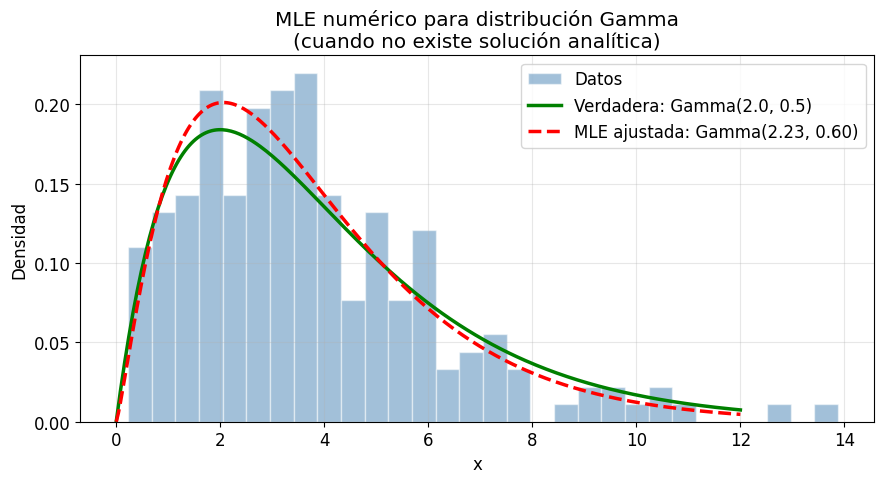

In [19]:
# Datos Gamma(alpha=2, beta=0.5)
alpha_true, beta_true = 2.0, 0.5
datos_gamma = np.random.gamma(shape=alpha_true, scale=1/beta_true, size=200)

# Log-verosimilitud de Gamma(alpha, beta)
# f(x|alpha,beta) = (beta^alpha / Gamma(alpha)) * x^(alpha-1) * exp(-beta*x)
from scipy.special import gammaln

def neg_log_lik_gamma(params, data):
    alpha, beta = params
    if alpha <= 0 or beta <= 0:
        return np.inf
    n = len(data)
    ll = (n * alpha * np.log(beta) - n * gammaln(alpha) 
          + (alpha - 1) * np.sum(np.log(data)) - beta * np.sum(data))
    return -ll  # negativa porque minimize minimiza

# Optimización numérica
result = optimize.minimize(
    neg_log_lik_gamma, 
    x0=[1.0, 1.0],  # valores iniciales
    args=(datos_gamma,),
    method='Nelder-Mead',
    options={'xatol': 1e-6, 'fatol': 1e-6}
)

alpha_hat, beta_hat = result.x

# scipy también puede ajustar directamente
alpha_scipy, loc_scipy, scale_scipy = stats.gamma.fit(datos_gamma, floc=0)
beta_scipy = 1 / scale_scipy

print("=== MLE numérico para Gamma(α, β) ===")
print(f"  True:          α={alpha_true}, β={beta_true}")
print(f"  Nelder-Mead:   α̂={alpha_hat:.4f}, β̂={beta_hat:.4f}")
print(f"  scipy.stats:   α̂={alpha_scipy:.4f}, β̂={beta_scipy:.4f}")

# Visualizar ajuste
x_plot = np.linspace(0, 12, 300)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(datos_gamma, bins=30, density=True, alpha=0.5, 
        color='steelblue', edgecolor='white', label='Datos')
ax.plot(x_plot, stats.gamma.pdf(x_plot, a=alpha_true, scale=1/beta_true), 
        'g-', lw=2.5, label=f'Verdadera: Gamma({alpha_true}, {beta_true})')
ax.plot(x_plot, stats.gamma.pdf(x_plot, a=alpha_hat, scale=1/beta_hat), 
        'r--', lw=2.5, label=f'MLE ajustada: Gamma({alpha_hat:.2f}, {beta_hat:.2f})')
ax.set_xlabel('x'); ax.set_ylabel('Densidad')
ax.set_title('MLE numérico para distribución Gamma\n(cuando no existe solución analítica)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. MLE como función del tamaño de muestra n: consistencia

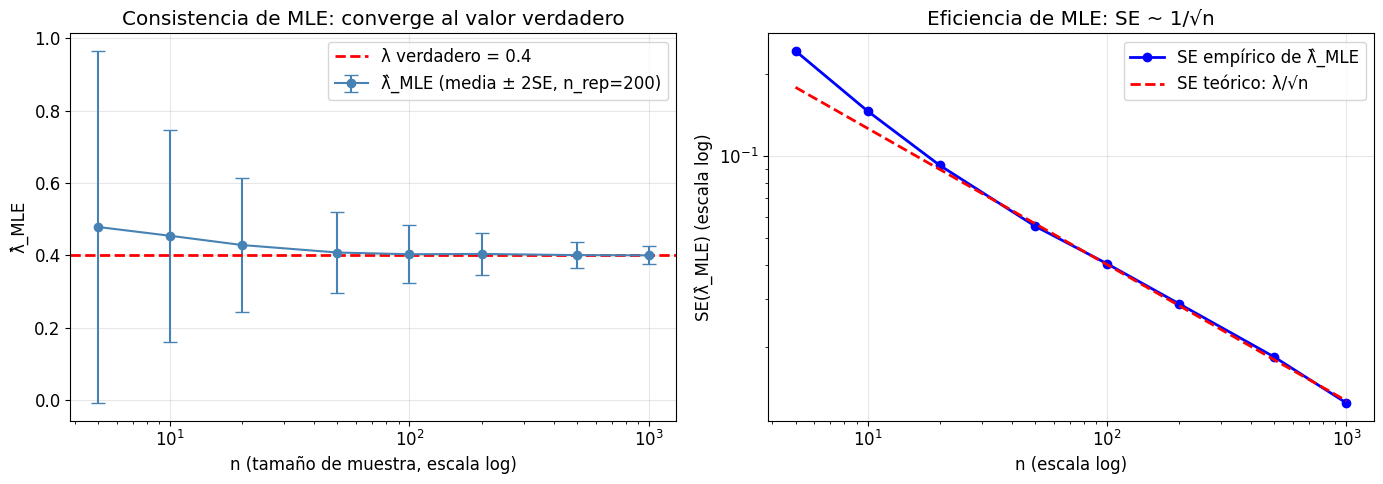

In [5]:
# MLE converge al valor verdadero cuando n crece
lambda_verdadero = 0.4
ns = [5, 10, 20, 50, 100, 200, 500, 1000]
n_rep = 200

medias_hat = []
ses_hat = []

for n in ns:
    lambdas_mle = []
    for _ in range(n_rep):
        muestra = np.random.exponential(1/lambda_verdadero, n)
        lambdas_mle.append(1/muestra.mean())
    medias_hat.append(np.mean(lambdas_mle))
    ses_hat.append(np.std(lambdas_mle))

medias_hat = np.array(medias_hat)
ses_hat = np.array(ses_hat)

# SE teórico: lambda/sqrt(n) (por el TLC)
se_teorico = lambda_verdadero / np.sqrt(np.array(ns))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.errorbar(ns, medias_hat, yerr=2*ses_hat, fmt='o-', color='steelblue',
            capsize=5, label='λ̂_MLE (media ± 2SE, n_rep=200)')
ax.axhline(lambda_verdadero, color='red', ls='--', lw=2, 
           label=f'λ verdadero = {lambda_verdadero}')
ax.set_xscale('log')
ax.set_xlabel('n (tamaño de muestra, escala log)')
ax.set_ylabel('λ̂_MLE')
ax.set_title('Consistencia de MLE: converge al valor verdadero')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.loglog(ns, ses_hat, 'b-o', ms=6, lw=2, label='SE empírico de λ̂_MLE')
ax.loglog(ns, se_teorico, 'r--', lw=2, label='SE teórico: λ/√n')
ax.set_xlabel('n (escala log)')
ax.set_ylabel('SE(λ̂_MLE) (escala log)')
ax.set_title('Eficiencia de MLE: SE ~ 1/√n')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. MLE = Cross-Entropy: la conexión con Machine Learning

Regresión logística por MLE (minimizando cross-entropy):
  θ̂ = [-0.25283004  3.03975945  6.01617032]
  Accuracy: 0.900
  Cross-entropy final: 0.1973


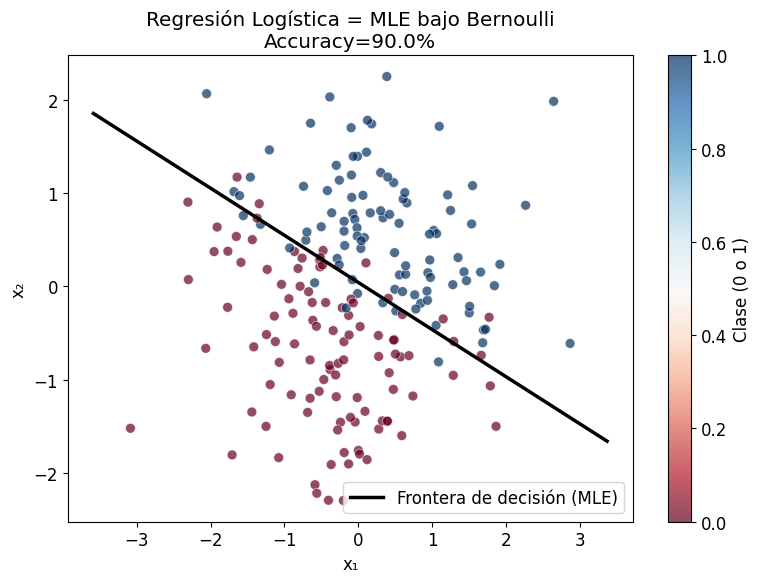


→ Entrenar la regresión logística con cross-entropy
  ES EQUIVALENTE a hacer MLE bajo el modelo Bernoulli.


In [ ]:
# Regresión logística: MLE bajo modelo Bernoulli
from scipy.special import expit  # función sigmoide = 1/(1+exp(-x))

# Generar datos de clasificación
np.random.seed(7)
n_cls = 200
X_cls = np.random.randn(n_cls, 2) # n_cls datos con 2 características
y_cls = (X_cls[:, 0] + 2*X_cls[:, 1] + np.random.randn(n_cls)*0.5 > 0).astype(float)

# Agregar intercepto
X_aug = np.column_stack([np.ones(n_cls), X_cls])

def logistic_loss(theta, X, y):
    """Cross-entropy = -log-verosimilitud de Bernoulli."""
    p = expit(X @ theta)
    p = np.clip(p, 1e-10, 1-1e-10)
    return -np.mean(y * np.log(p) + (1-y) * np.log(1-p))

# Gradiente de la función de pérdida
def grad_logistic(theta, X, y):
    p = expit(X @ theta)
    return X.T @ (p - y) / len(y)

# Minimizar con scipy
theta0 = np.zeros(3)
result_lr = optimize.minimize(logistic_loss, theta0, args=(X_aug, y_cls),
                               jac=grad_logistic, method='L-BFGS-B')
theta_hat_lr = result_lr.x

# Evaluar
p_hat = expit(X_aug @ theta_hat_lr)
y_pred = (p_hat > 0.5).astype(float)
accuracy = (y_pred == y_cls).mean()

print(f"Regresión logística por MLE (minimizando cross-entropy):")
print(f"  θ̂ = {theta_hat_lr}")
print(f"  Accuracy: {accuracy:.3f}")
print(f"  Cross-entropy final: {logistic_loss(theta_hat_lr, X_aug, y_cls):.4f}")

# Visualizar
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls, 
                     cmap='RdBu', alpha=0.7, s=50, edgecolors='white', lw=0.5)

# Frontera de decisión: theta[0] + theta[1]*x1 + theta[2]*x2 = 0
x1_range = np.linspace(X_cls[:, 0].min()-0.5, X_cls[:, 0].max()+0.5, 100)
b, w1, w2 = theta_hat_lr
x2_boundary = -(b + w1 * x1_range) / w2
ax.plot(x1_range, x2_boundary, 'k-', lw=2.5, label='Frontera de decisión (MLE)')

ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title(f'Regresión Logística = MLE bajo Bernoulli\nAccuracy={accuracy:.1%}')
plt.colorbar(scatter, ax=ax, label='Clase (0 o 1)')
ax.legend()
plt.tight_layout()
plt.show()

print("\n→ Entrenar la regresión logística con cross-entropy")
print("  ES EQUIVALENTE a hacer MLE bajo el modelo Bernoulli.")

## Resumen

- **MLE**: encontrar θ que maximiza P(datos|θ). En la práctica, maximizar ℓ(θ) = Σ log f(xᵢ|θ).
- **Distribuciones comunes**: Normal → μ̂=x̄, σ̂²=varianza muestral; Exp → λ̂=1/x̄; Poisson → λ̂=x̄.
- **Sin solución analítica** (Gamma, Beta, mezclas): usar scipy.optimize.
- **Consistencia**: λ̂_MLE → λ* cuando n→∞. SE ~ λ/√n.
- **Conexión con ML**: minimizar cross-entropy = hacer MLE bajo modelo Bernoulli (clasificación).